In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/breast-cancer-detection/valid/0/2030_992775426_png.rf.df85416a26dd4cb665bb104d6a34d303.jpg
/kaggle/input/breast-cancer-detection/valid/0/2564_1570678080_png.rf.135a908f06be029039778a6df2ab5149.jpg
/kaggle/input/breast-cancer-detection/valid/0/2704_781524556_png.rf.c3007300f84e02ef651821761af1c8a9.jpg
/kaggle/input/breast-cancer-detection/valid/0/294_2044098614_png.rf.1f17493146bfa674226f43a711f6c141.jpg
/kaggle/input/breast-cancer-detection/valid/0/866_1033311478_png.rf.ff97b307c7b296343424c8e5aa172c27.jpg
/kaggle/input/breast-cancer-detection/valid/0/370_1943620586_png.rf.6b2845edfbb223f65f126beabd7aee6a.jpg
/kaggle/input/breast-cancer-detection/valid/0/2546_730952035_png.rf.0aa3bdf9935f0ebed78558c5259bc6bb.jpg
/kaggle/input/breast-cancer-detection/valid/0/2282_2092132689_png.rf.8b110ae2768e8650d7b30dce6ed00e36.jpg
/kaggle/input/breast-cancer-detection/valid/0/561_1308043124_png.rf.e7f17d151c0e2df684b5569befe144f1.jpg
/kaggle/input/breast-cancer-detection/valid/0/2112_19

In [3]:
base_path = "/kaggle/input/breast-cancer-detection/train"
categories = ["0","1"]

In [4]:
image_paths = []
labels = []

for category in categories:
    category_path = os.path.join(base_path, category)
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)
        image_paths.append(image_path)
        labels.append(category)  

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

In [5]:
df.head()

,image_path,label
0,/kaggle/input/breast-cancer-detection/train/0/...,0
1,/kaggle/input/breast-cancer-detection/train/0/...,0
2,/kaggle/input/breast-cancer-detection/train/0/...,0
3,/kaggle/input/breast-cancer-detection/train/0/...,0
4,/kaggle/input/breast-cancer-detection/train/0/...,0


In [6]:
df.tail()

,image_path,label
2367,/kaggle/input/breast-cancer-detection/train/1/...,1
2368,/kaggle/input/breast-cancer-detection/train/1/...,1
2369,/kaggle/input/breast-cancer-detection/train/1/...,1
2370,/kaggle/input/breast-cancer-detection/train/1/...,1
2371,/kaggle/input/breast-cancer-detection/train/1/...,1


In [7]:
df.shape

(2372, 2)

In [8]:
df.columns

Index(['image_path', 'label'], dtype='object')

In [9]:
df.duplicated().sum()

0

In [10]:
df.isnull().sum()

image_path    0
label         0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372 entries, 0 to 2371
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  2372 non-null   object
 1   label       2372 non-null   object
dtypes: object(2)
memory usage: 37.2+ KB


In [12]:
df['label'].unique()

array(['0', '1'], dtype=object)

In [13]:
df['label'].value_counts()

label
0    1569
1     803
Name: count, dtype: int64

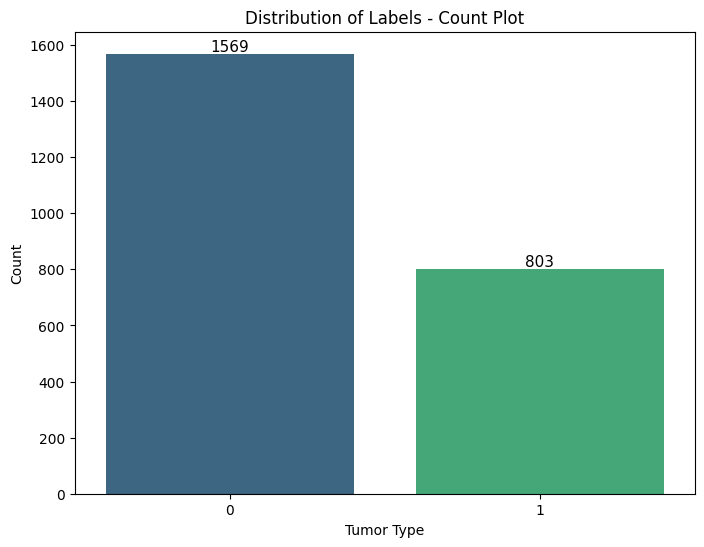

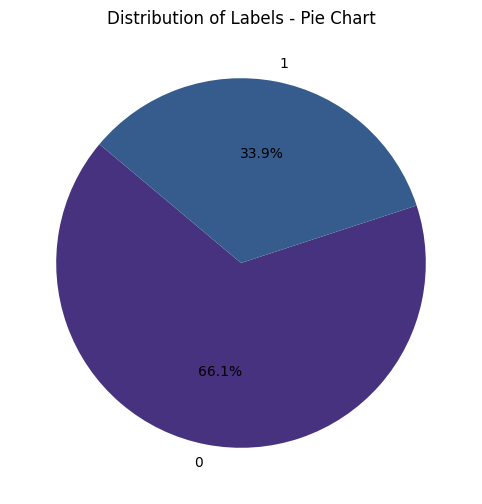

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="label", palette="viridis")
plt.title("Distribution of Labels - Count Plot")
plt.xlabel("Tumor Type")
plt.ylabel("Count")

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), 
                       textcoords='offset points')

plt.show()

label_counts = df['label'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis"))
plt.title("Distribution of Labels - Pie Chart")
plt.show()

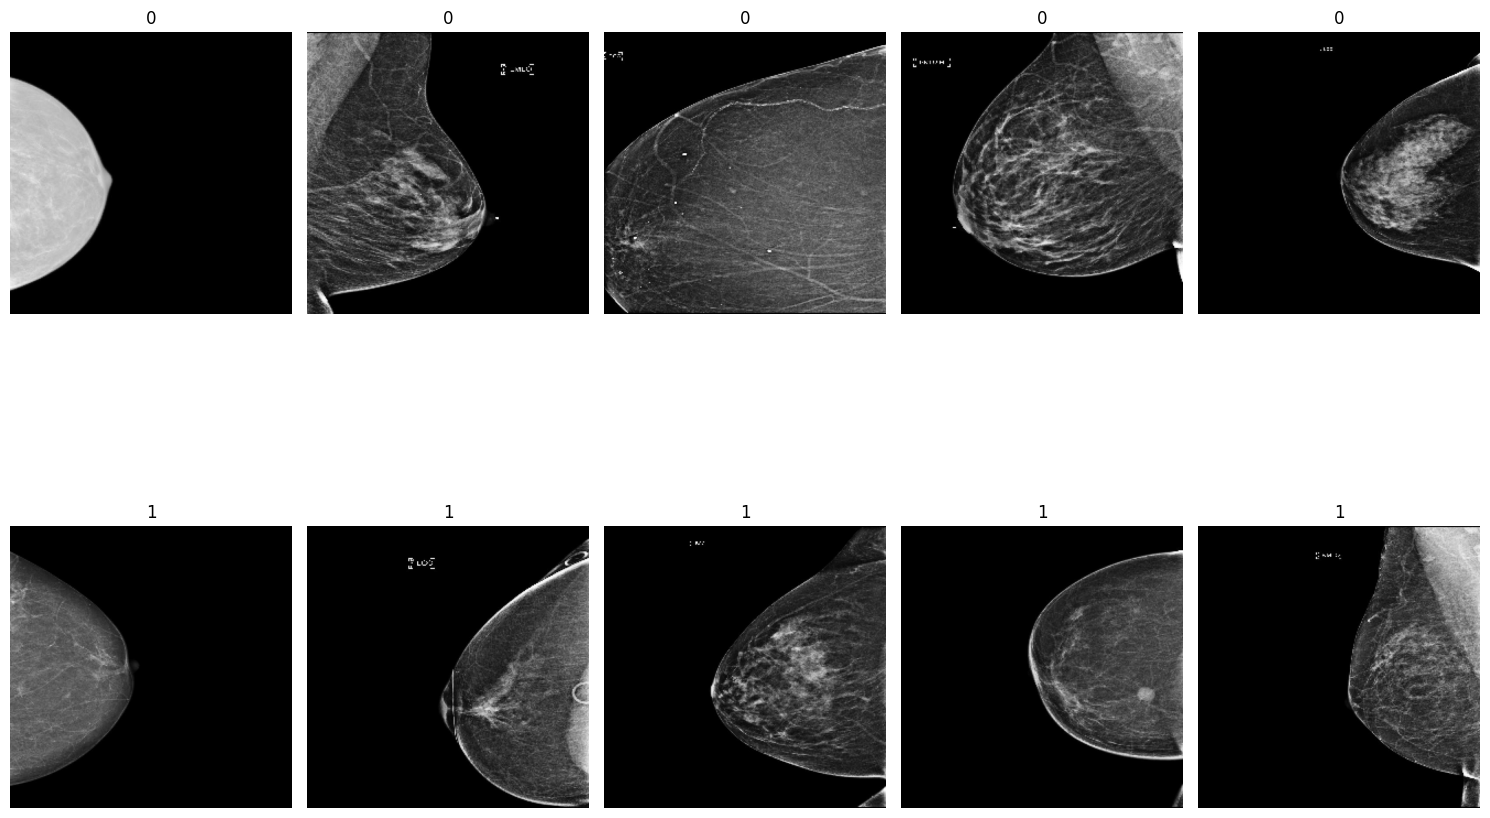

In [15]:
import cv2

num_images = 5

plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_images = df[df['label'] == category]['image_path'].iloc[:num_images]

    for j, img_path in enumerate(category_images):

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  

        plt.subplot(len(categories), num_images, i * num_images + j + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(category)

plt.tight_layout()
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['category_encoded'] = label_encoder.fit_transform(df['label'])

In [18]:
df = df[['image_path', 'category_encoded']]

In [19]:
from imblearn.over_sampling import RandomOverSampler

In [24]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(df[['image_path']], df['category_encoded'])

In [25]:
df_resampled = pd.DataFrame(X_resampled, columns=['image_path'])
df_resampled['category_encoded'] = y_resampled

In [26]:
print("\nClass distribution after oversampling:")
print(df_resampled['category_encoded'].value_counts())


Class distribution after oversampling:
category_encoded
0    1569
1    1569
Name: count, dtype: int64


In [27]:
df_resampled

,image_path,category_encoded
0,/kaggle/input/breast-cancer-detection/train/0/...,0
1,/kaggle/input/breast-cancer-detection/train/0/...,0
2,/kaggle/input/breast-cancer-detection/train/0/...,0
3,/kaggle/input/breast-cancer-detection/train/0/...,0
4,/kaggle/input/breast-cancer-detection/train/0/...,0
...,...,...
3133,/kaggle/input/breast-cancer-detection/train/1/...,1
3134,/kaggle/input/breast-cancer-detection/train/1/...,1
3135,/kaggle/input/breast-cancer-detection/train/1/...,1
3136,/kaggle/input/breast-cancer-detection/train/1/...,1


In [29]:
df_resampled['category_encoded'] = df_resampled['category_encoded'].astype(str)

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('check')

check


In [31]:
train_df_new, temp_df_new = train_test_split(
    df_resampled,
    train_size=0.8,  
    shuffle=True,
    random_state=42,
    stratify=df_resampled['category_encoded']  
)

valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,  
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['category_encoded'] 
)

In [32]:
batch_size = 16
img_size = (256, 256)
channels = 3  
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(rescale=1./255)  
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new = tr_gen.flow_from_dataframe(
    train_df_new,
    x_col='image_path',  
    y_col='category_encoded',     
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb', 
    shuffle=True,
    batch_size=batch_size
)

valid_gen_new = ts_gen.flow_from_dataframe(
    valid_df_new,
    x_col='image_path',  
    y_col='category_encoded',     
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb', 
    shuffle=True,
    batch_size=batch_size
)

test_gen_new = ts_gen.flow_from_dataframe(
    test_df_new,
    x_col='image_path', 
    y_col='category_encoded',    
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb', 
    shuffle=False,  
    batch_size=batch_size
)

Found 2510 validated image filenames belonging to 2 classes.
Found 314 validated image filenames belonging to 2 classes.
Found 314 validated image filenames belonging to 2 classes.


In [34]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


In [35]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is set for TensorFlow")
    except RuntimeError as e:
        print(e)

GPU is set for TensorFlow


In [36]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau

def dilated_conv_block(x, filters, dilation_rate=2):
    x = layers.Conv2D(filters, (3, 3), dilation_rate=dilation_rate, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def pcam_block(x, filters):
  
    x = layers.Conv2D(filters, (1, 1), padding='same')(x)  
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    attention = layers.GlobalAveragePooling2D()(x)
    attention = layers.Dense(filters, activation='sigmoid')(attention)
    attention = layers.Reshape((1, 1, filters))(attention)
    x = layers.multiply([x, attention])
    return x

def ha_encoder(input_shape=(256, 256, 3), filters=64):
    inputs = layers.Input(shape=input_shape)
    x = dilated_conv_block(inputs, filters)
    x = pcam_block(x, filters)
    x = dilated_conv_block(x, filters*2)
    x = pcam_block(x, filters*2)
    return models.Model(inputs, x)

def msfr_decoder(encoder_output, filters=64):
    x = layers.UpSampling2D(size=(2, 2))(encoder_output)
    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x  

def pinn_loss(y_true, y_pred, physical_loss_weight=0.1): 
    classification_loss = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    physical_loss = tf.reduce_mean(tf.abs(y_pred - y_true)) 
    total_loss = classification_loss + physical_loss_weight * physical_loss
    return total_loss

def pinn_emfnet(input_shape=(256, 256, 3), filters=64):
    encoder = ha_encoder(input_shape=input_shape, filters=filters)
    encoder_output = encoder.output

    decoder_output = msfr_decoder(encoder_output, filters)

    refined_output = layers.Flatten()(decoder_output)  
    refined_output = layers.Dense(1, activation='sigmoid')(refined_output) 

    model = models.Model(inputs=encoder.input, outputs=refined_output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss=pinn_loss, metrics=['accuracy'])
    return model

img_size = (256, 256)
batch_size = 8
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new = tr_gen.flow_from_dataframe(
    train_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen_new = ts_gen.flow_from_dataframe(
    valid_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

test_gen_new = ts_gen.flow_from_dataframe(
    test_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

model = pinn_emfnet(input_shape=(256, 256, 3), filters=32) 
model.summary()

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

Found 2510 validated image filenames belonging to 2 classes.
Found 314 validated image filenames belonging to 2 classes.
Found 314 validated image filenames belonging to 2 classes.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 256, 32)   │            896 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 32)   │            128 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu (ReLU)              │ (None, 256, 256, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 256, 32)   │          1,056 │ re_lu[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 256, 256, 32)   │            128 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_1 (ReLU)            │ (None, 256, 256, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 32)             │              0 │ re_lu_1[0][0]          │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 32)             │          1,056 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1, 1, 32)       │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 256, 256, 32)   │              0 │ re_lu_1[0][0],         │
│                           │                        │                │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 256, 256, 64)   │         18,496 │ multiply[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 256, 256, 64)   │            256 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_2 (ReLU)            │ (None, 256, 256, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 256, 256, 64)   │          4,160 │ re_lu_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 256, 256, 64)   │            256 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_3 (ReLU)       

 Total params: 8,437,793 (32.19 MB)

 Trainable params: 8,437,345 (32.19 MB)

 Non-trainable params: 448 (1.75 KB)

In [38]:
from PIL import Image

def my_image_check(generator):  
    while True:
        x, y = next(generator) 
        new_x = []
        new_y = []
        for i in range(x.shape[0]):  
            try:
                img = Image.fromarray((x[i] * 255).astype(np.uint8))
                img.verify()
                new_x.append(x[i])
                new_y.append(y[i])
            except Exception as e:
                print(f"Error loading image: {generator.dataframe['image_path'].iloc[generator.index + i] if (generator.index + i) < len(generator.dataframe) else 'Path information not available'}") 
                print(f"Error: {e}")
        yield np.array(new_x), np.array(new_y)

tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)

train_generator = tr_gen.flow_from_dataframe(
    train_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)
train_gen_new = my_image_check(train_generator)  

valid_generator = ts_gen.flow_from_dataframe(
    valid_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen_new = my_image_check(valid_generator)  

test_generator = ts_gen.flow_from_dataframe(
    test_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

test_gen_new = my_image_check(test_generator)  


steps_per_epoch = len(train_df_new) // batch_size
validation_steps = len(valid_df_new) // batch_size

history = model.fit(
    train_gen_new,
    epochs=5,
    validation_data=valid_gen_new,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[lr_scheduler]
)

Found 2510 validated image filenames belonging to 2 classes.
Found 314 validated image filenames belonging to 2 classes.
Found 314 validated image filenames belonging to 2 classes.
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 147ms/step - accuracy: 0.5423 - loss: 23.7250 - val_accuracy: 0.5513 - val_loss: 7.8044 - learning_rate: 1.0000e-04
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 186ms/step - accuracy: 0.7754 - loss: 6.4262 - val_accuracy: 0.5065 - val_loss: 24.1468 - learning_rate: 1.0000e-04
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.8751 - loss: 3.5085 - val_accuracy: 0.7712 - val_loss: 11.2738 - learning_rate: 1.0000e-04
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.9632 - loss: 0.5473 - val_accuracy: 0.8007 - val_loss: 6.4297 - learning_rate: 5.0000e-05
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.9706 - loss: 0.2974 - val_accuracy: 0.8105 - val_loss: 5.4039 - learning_rate: 5.0000e-05


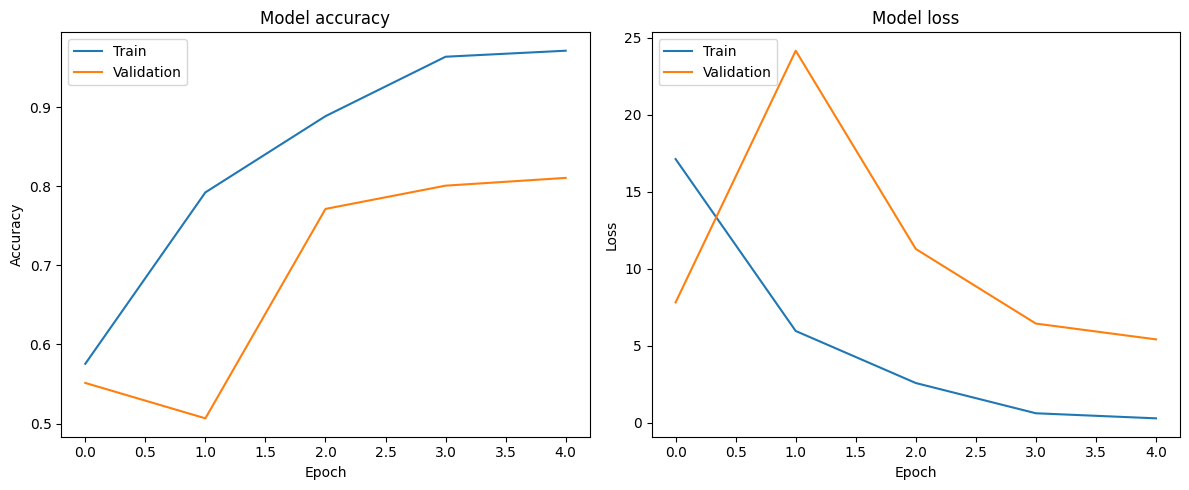

In [39]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout() 
plt.show()